<a href="https://colab.research.google.com/github/afthalla2929/MScBA-Files/blob/Project_and_Case_Studies/MBN603_Telco_Churn_Final_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MBN 603 Final Case-Based Assessment
## Option B - Telecom Customer Churn Prediction

**Ali Eissa 20250007026, Nahla Saleh 20250007566
, Fatma Alblooshi 20250007606**


**Business question:** What factors drive telecom customer churn, and how can PCA affect churn prediction performance?

This notebook is designed to run end-to-end using the included dataset file: `/content/WA_Fn-UseC_-Telco-Customer-Churn.csv`.

In [75]:
# 1. Setup
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

RANDOM_STATE = 42
DATA_PATH = os.path.join('data','/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Load and inspect the dataset
We first confirm the file shape, column names, data types, missing values, and duplicate rows.

In [76]:
DATA_PATH = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df_raw = pd.read_csv(DATA_PATH)
print('Shape:', df_raw.shape)
display(df_raw.head())
print('Columns:', df_raw.columns.tolist())
print('Duplicate rows:', df_raw.duplicated().sum())
df_raw.info()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    70

## 3. Data cleaning and feature engineering
`TotalCharges` is stored as text. Blank values occur for new customers with tenure = 0, so they are treated as zero total charges. New features are created for customer tenure stage, charge intensity, and service adoption.

Missing TotalCharges before treatment: 11
Missing TotalCharges after treatment: 0
Overall churn rate: 0.265


,tenure,tenure_group,MonthlyCharges,TotalCharges,monthly_to_total_ratio,service_count,Churn
0,1,0-12,29.85,29.85,0.967585,1,No
1,34,25-48,56.95,1889.50,0.030124,3,No
2,2,0-12,53.85,108.15,0.493358,3,Yes
3,45,25-48,42.30,1840.75,0.022967,3,No
4,2,0-12,70.70,151.65,0.463151,1,Yes


Summary statistics for numeric variables:


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


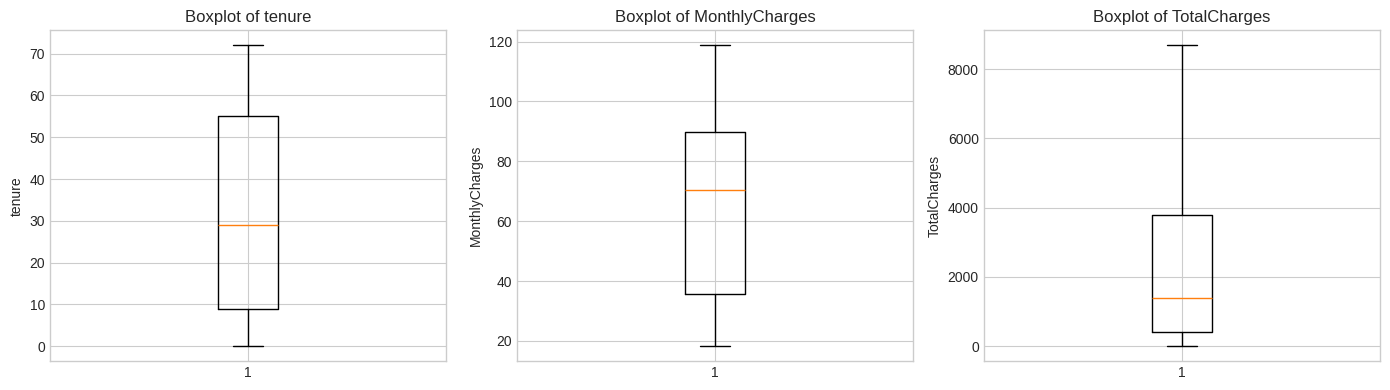

No rows were removed because the observed values were plausible for telecom customer data.


In [77]:
df = df_raw.copy()

# Convert TotalCharges from string to numeric and handle blanks
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Missing TotalCharges before treatment:', df['TotalCharges'].isna().sum())

mask_tenure_zero = (df['tenure'] == 0) & (df['TotalCharges'].isna())
df.loc[mask_tenure_zero, 'TotalCharges'] = 0
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print('Missing TotalCharges after treatment:', df['TotalCharges'].isna().sum())

# Target variable
df['ChurnFlag'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Feature engineering
df['tenure_group'] = pd.cut(
    df['tenure'], bins=[-1, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49-72']
)
df['monthly_to_total_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

service_cols = [
    'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
df['service_count'] = df[service_cols].apply(lambda row: sum(value == 'Yes' for value in row), axis=1)

print('Overall churn rate:', round(df['ChurnFlag'].mean(), 3))
display(df[['tenure','tenure_group','MonthlyCharges','TotalCharges','monthly_to_total_ratio','service_count','Churn']].head())

numeric_review_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Summary statistics for numeric variables:")
display(df[numeric_review_cols].describe())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, numeric_review_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(f'Boxplot of {col}')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('numeric_outlier_review.png', dpi=150)
plt.show()

print("No rows were removed because the observed values were plausible for telecom customer data.")

## 4. Exploratory Data Analysis
The required EDA includes at least four visualizations: churn count, churn by contract type, tenure distribution, and monthly charges by churn status.

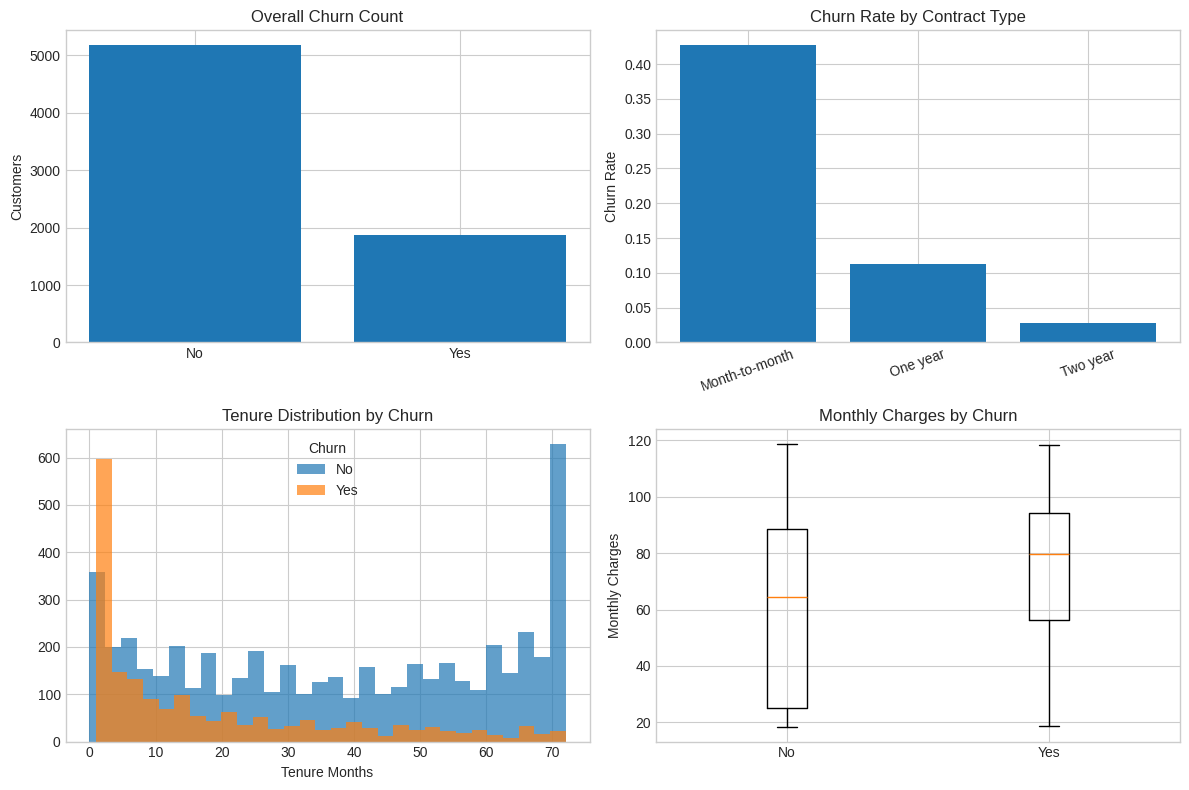

Churn by contract:


,Churn Rate %
Contract,
Month-to-month,42.7
One year,11.3
Two year,2.8


Churn by tenure group:


,Churn Rate %
tenure_group,
0-12,47.4
13-24,28.7
25-48,20.4
49-72,9.5


In [78]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Overall churn count
counts = df['Churn'].value_counts().reindex(['No','Yes'])
axes[0,0].bar(counts.index, counts.values)
axes[0,0].set_title('Overall Churn Count')
axes[0,0].set_ylabel('Customers')

# 2. Churn by contract
contract_churn = df.groupby('Contract')['ChurnFlag'].mean().sort_values(ascending=False)
axes[0,1].bar(contract_churn.index, contract_churn.values)
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate')
axes[0,1].tick_params(axis='x', rotation=20)

# 3. Tenure distribution by churn
axes[1,0].hist(df.loc[df['Churn']=='No','tenure'], bins=30, alpha=0.7, label='No')
axes[1,0].hist(df.loc[df['Churn']=='Yes','tenure'], bins=30, alpha=0.7, label='Yes')
axes[1,0].set_title('Tenure Distribution by Churn')
axes[1,0].set_xlabel('Tenure Months')
axes[1,0].legend(title='Churn')

# 4. Monthly charges by churn
axes[1,1].boxplot([
    df.loc[df['Churn']=='No','MonthlyCharges'],
    df.loc[df['Churn']=='Yes','MonthlyCharges']
], labels=['No','Yes'])
axes[1,1].set_title('Monthly Charges by Churn')
axes[1,1].set_ylabel('Monthly Charges')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

print('Churn by contract:')
display((contract_churn * 100).round(1).to_frame('Churn Rate %'))
print('Churn by tenure group:')
display((df.groupby('tenure_group', observed=False)['ChurnFlag'].mean() * 100).round(1).to_frame('Churn Rate %'))

## 5. Correlation analysis
Correlation is used as a first signal of relationships; it does not prove causation.

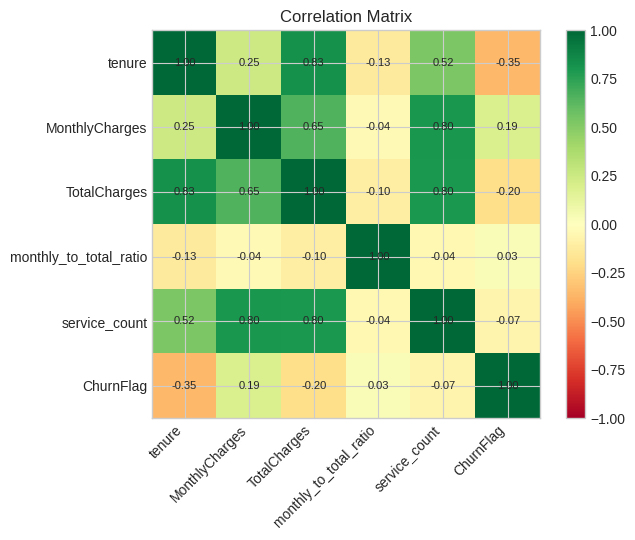

,Correlation with Churn
ChurnFlag,1.000
MonthlyCharges,0.193
monthly_to_total_ratio,0.026
service_count,-0.067
TotalCharges,-0.198
tenure,-0.352


In [79]:
num_cols = ['tenure','MonthlyCharges','TotalCharges','monthly_to_total_ratio','service_count','ChurnFlag']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

display(corr['ChurnFlag'].sort_values(ascending=False).round(3).to_frame('Correlation with Churn'))

## 6. Encoding and train-test split
All categorical variables are encoded using one-hot encoding. The target is `ChurnFlag`, and the split is 80/20 with stratification.

In [80]:
X_raw = df.drop(columns=['customerID','Churn','ChurnFlag'])
y = df['ChurnFlag']

X = pd.get_dummies(X_raw, drop_first=True)
print('Encoded matrix:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Encoded matrix: (7043, 35)
Train: (5634, 35) Test: (1409, 35)


## 7. Baseline model: Logistic Regression
Logistic Regression is the mandatory baseline for the classification task. Features are standardized before training.

In [81]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logit = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
logit.fit(X_train_scaled, y_train)

y_pred_logit = logit.predict(X_test_scaled)
y_proba_logit = logit.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression - Original Features')
print('Accuracy:', round(accuracy_score(y_test, y_pred_logit), 3))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_logit), 3))
print(classification_report(y_test, y_pred_logit, target_names=['No Churn','Churn']))
display(pd.DataFrame(confusion_matrix(y_test, y_pred_logit),
                     index=['Actual No','Actual Yes'],
                     columns=['Pred No','Pred Yes']))

Logistic Regression - Original Features
Accuracy: 0.799
ROC-AUC: 0.842
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



,Pred No,Pred Yes
Actual No,931,104
Actual Yes,179,195


## 8. Additional model: Random Forest
Random Forest is used as the comparison model because it can capture non-linear relationships and interactions.

In [82]:
rf = RandomForestClassifier(
    n_estimators=150, random_state=RANDOM_STATE, class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest - Original Features')
print('Accuracy:', round(accuracy_score(y_test, y_pred_rf), 3))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_rf), 3))
print(classification_report(y_test, y_pred_rf, target_names=['No Churn','Churn']))

Random Forest - Original Features
Accuracy: 0.791
ROC-AUC: 0.822
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## 9. PCA: standardization, scree plot, and component selection
PCA is applied to standardized encoded features. The selected number of components is the minimum needed to explain at least 90% of variance.

Components needed for at least 90% explained variance: 17
Variance retained: 0.911


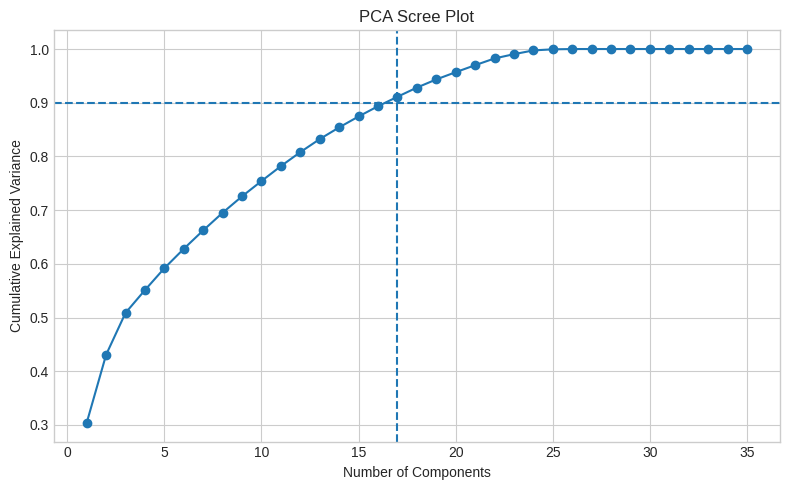

In [83]:
pca_all = PCA(random_state=RANDOM_STATE)
pca_all.fit(X_train_scaled)
explained = pca_all.explained_variance_ratio_
cum_explained = np.cumsum(explained)
n_components_90 = np.argmax(cum_explained >= 0.90) + 1
print('Components needed for at least 90% explained variance:', n_components_90)
print('Variance retained:', round(cum_explained[n_components_90-1], 3))

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained)+1), cum_explained, marker='o')
plt.axhline(0.90, linestyle='--')
plt.axvline(n_components_90, linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.tight_layout()
plt.savefig('pca_scree_plot.png', dpi=150)
plt.show()

## 10. PCA visualization and PCA-based model
A 2D PCA plot is shown for visual interpretation. Then Logistic Regression is trained on the selected PCA components for original-vs-PCA comparison.

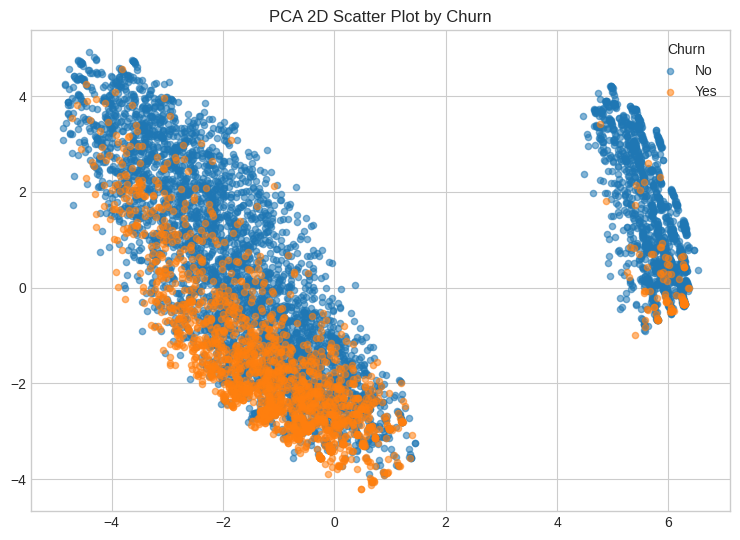

Logistic Regression - PCA Features
Accuracy: 0.787
ROC-AUC: 0.828
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.62      0.52      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [84]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2.fit_transform(scaler.fit_transform(X))
pca_plot = pd.DataFrame({'PC1': X_2d[:,0], 'PC2': X_2d[:,1], 'Churn': df['Churn']})

plt.figure(figsize=(7.5, 5.5))
for label, group in pca_plot.groupby('Churn'):
    plt.scatter(group['PC1'], group['PC2'], alpha=0.55, s=20, label=label)
plt.legend(title='Churn')
plt.title('PCA 2D Scatter Plot by Churn')
plt.tight_layout()
plt.savefig('pca_2d_scatter.png', dpi=150)
plt.show()

pca = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

logit_pca = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
logit_pca.fit(X_train_pca, y_train)
y_pred_pca = logit_pca.predict(X_test_pca)
y_proba_pca = logit_pca.predict_proba(X_test_pca)[:,1]

print('Logistic Regression - PCA Features')
print('Accuracy:', round(accuracy_score(y_test, y_pred_pca), 3))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_pca), 3))
print(classification_report(y_test, y_pred_pca, target_names=['No Churn','Churn']))



## 11. Principal component interpretation
The strongest loadings help translate PCA components into business meaning.

In [85]:
# ------------------------------------------------------------
# PCA interpretation: nickname and explain PC1, PC2, and PC3
# ------------------------------------------------------------

# Create a loading table.
# Loadings show how strongly each original feature contributes
# to each principal component.
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Create interpretation table for the first three principal components
pc_interpretation = pd.DataFrame({
    "Principal Component": ["PC1", "PC2", "PC3"],
    "Nickname": [
        "Service Cost Profile",
        "Customer Loyalty Profile",
        "Service Bundle Profile"
    ],
    "Explained Variance": [
        pca.explained_variance_ratio_[0],
        pca.explained_variance_ratio_[1],
        pca.explained_variance_ratio_[2]
    ],
    "Business Interpretation": [
        "Captures internet-service type, monthly charges, and billing intensity. It separates customers based on how costly or service-heavy their telecom plan is.",
        "Captures tenure, long contracts, total charges, and service count. It reflects customer maturity, loyalty, and accumulated relationship value.",
        "Captures phone/fiber setup and streaming-service combinations. It shows how customers differ in the mix of telecom services they subscribe to."
    ]
})

# Convert explained variance to percentage format
pc_interpretation["Explained Variance"] = (
    pc_interpretation["Explained Variance"] * 100
).round(1).astype(str) + "%"

display(pc_interpretation)

# Show the strongest contributing original features for PC1, PC2, and PC3
for pc in ["PC1", "PC2", "PC3"]:
    print(f"\nTop contributing features for {pc}:")

    top_features = (
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .head(8)
    )

    display(top_features)

# Simple text summary for the notebook
print("\nPCA interpretation summary:")
print("PC1 - Service Cost Profile: captures internet-service type, monthly charges, and billing intensity.")
print("PC2 - Customer Loyalty Profile: captures tenure, long contracts, total charges, and service count.")
print("PC3 - Service Bundle Profile: captures phone/fiber setup and streaming-service combinations.")

,Principal Component,Nickname,Explained Variance,Business Interpretation
0,PC1,Service Cost Profile,30.4%,"Captures internet-service type, monthly charge..."
1,PC2,Customer Loyalty Profile,12.7%,"Captures tenure, long contracts, total charges..."
2,PC3,Service Bundle Profile,7.8%,Captures phone/fiber setup and streaming-servi...



Top contributing features for PC1:


,PC1
InternetService_No,0.283708
DeviceProtection_No internet service,0.283708
OnlineBackup_No internet service,0.283708
StreamingTV_No internet service,0.283708
TechSupport_No internet service,0.283708
OnlineSecurity_No internet service,0.283708
StreamingMovies_No internet service,0.283708
MonthlyCharges,0.277046



Top contributing features for PC2:


,PC2
tenure,0.394817
tenure_group_49-72,0.358581
Contract_Two year,0.322131
TotalCharges,0.317298
service_count,0.223868
Partner_Yes,0.212507
PaymentMethod_Electronic check,0.196713
MultipleLines_Yes,0.151548



Top contributing features for PC3:


,PC3
PhoneService_Yes,0.515808
MultipleLines_No phone service,0.515808
InternetService_Fiber optic,0.347441
MultipleLines_Yes,0.266565
MonthlyCharges,0.222707
OnlineSecurity_Yes,0.183073
TechSupport_Yes,0.174345
PaymentMethod_Electronic check,0.170094



PCA interpretation summary:
PC1 - Service Cost Profile: captures internet-service type, monthly charges, and billing intensity.
PC2 - Customer Loyalty Profile: captures tenure, long contracts, total charges, and service count.
PC3 - Service Bundle Profile: captures phone/fiber setup and streaming-service combinations.


## 12. Model comparison and export
This table compares the mandatory baseline, the additional model, and the PCA-transformed feature model.

In [86]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression - Original', 'Random Forest - Original', 'Logistic Regression - PCA'],
    'Accuracy': [accuracy_score(y_test, y_pred_logit), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_pca)],
    'Precision': [precision_score(y_test, y_pred_logit), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_pca)],
    'Recall': [recall_score(y_test, y_pred_logit), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_pca)],
    'F1': [f1_score(y_test, y_pred_logit), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_pca)],
    'ROC_AUC': [roc_auc_score(y_test, y_proba_logit), roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_pca)]
}).round(3)

display(summary)
summary.to_csv('model_comparison_summary.csv', index=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression - Original,0.799,0.652,0.521,0.579,0.842
1,Random Forest - Original,0.791,0.642,0.484,0.552,0.822
2,Logistic Regression - PCA,0.787,0.619,0.516,0.563,0.828


## 13. Business recommendations and conclusion
1. **Prioritize early-tenure customers:** The first 12 months show the highest churn risk, so onboarding, first-bill support, and early usage check-ins should be strengthened.
2. **Reduce month-to-month contract risk:** Offer targeted migration incentives from month-to-month to annual contracts for customers with high churn probability.
3. **Investigate billing/service pain points:** Electronic check and fiber-optic customers show high churn risk, suggesting the need to review billing friction, technical support, and service quality.
4. **Use churn probability to rank campaigns:** Treat model probabilities as a retention priority score so budget is focused on the highest-risk customers.

PCA reduced the dimensionality of the encoded feature space with limited performance loss, but the original Logistic Regression model is recommended for business use because it was more accurate and more interpretable.